# Système web intelligent de détection de clics suspects et d’optimisation du ROI publicitaire

## Projet Data Mining — Méthodologie KDD

Ce notebook construit la partie **data science** du projet :

1. Compréhension du problème métier  
2. Exploration du dataset TalkingData  
3. Prétraitement des logs de clics  
4. Feature engineering comportemental  
5. Détection d’anomalies  
6. Modélisation supervisée  
7. Score de risque pour intégration temps réel  
8. Analyse ROI avant/après filtrage  
9. Export des artefacts pour l’API et le dashboard  

## Point méthodologique important

Le système ne prouve pas juridiquement la fraude.  
Il détecte des **clics suspects**, **anormaux** ou **de faible qualité** à partir de patterns comportementaux.

## 1. Contexte du projet

Les campagnes publicitaires digitales peuvent être affectées par des clics suspects : clics automatisés, clics répétés, comportements non humains, trafic de faible qualité.

Dans un modèle publicitaire au coût par clic, ces clics peuvent :

- augmenter artificiellement les dépenses ;
- diminuer le ROI marketing ;
- fausser les indicateurs de performance ;
- réduire la confiance dans les campagnes.

L’objectif est de construire un prototype qui analyse les clics, calcule un score de risque et permet d’exclure les clics suspects.

## 2. Objectifs

Objectif général :

Développer un prototype intelligent capable de détecter les clics suspects et d’optimiser le ROI publicitaire.

Objectifs spécifiques :

- appliquer la méthodologie KDD ;
- analyser un dataset réel de click tracking ;
- créer des variables comportementales ;
- entraîner des modèles de machine learning ;
- produire un score de risque utilisable par une API temps réel ;
- estimer l’impact business avec un calcul ROI.

## 3. Dataset utilisé

Dataset recommandé : **TalkingData AdTracking Fraud Detection Challenge**

Colonnes principales :

- `ip` : identifiant anonymisé de l’adresse IP ;
- `app` : application publicitaire ;
- `device` : type d’appareil ;
- `os` : système d’exploitation ;
- `channel` : canal publicitaire ;
- `click_time` : horodatage du clic ;
- `attributed_time` : heure de conversion si elle existe ;
- `is_attributed` : cible indiquant si le clic a mené à une conversion.

Interprétation :

- `is_attributed = 1` : clic converti ;
- `is_attributed = 0` : clic non converti.

Un clic non converti n’est pas automatiquement une fraude. Dans ce projet, il représente plutôt un signal de **faible qualité potentielle**.

## 4. Importation des bibliothèques

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

OUTPUT_DIR = Path("/kaggle/working")
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
TABLE_DIR = OUTPUT_DIR / "tables"

for d in [FIG_DIR, MODEL_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 5. Localisation du fichier `train.csv`

Cette cellule cherche automatiquement le fichier `train.csv` ou `train.csv.zip` dans `/kaggle/input`.

In [2]:
def find_train_file():
    candidates = []
    for root, _, files in os.walk("/kaggle/input"):
        for f in files:
            if f in ["train.csv", "train.csv.zip"]:
                candidates.append(os.path.join(root, f))
    if not candidates:
        raise FileNotFoundError("Aucun fichier train.csv ou train.csv.zip trouvé dans /kaggle/input.")
    return candidates[0]

train_path = find_train_file()
print("Fichier utilisé :", train_path)

Fichier utilisé : /kaggle/input/competitions/talkingdata-adtracking-fraud-detection/train.csv


## 6. Chargement d’un échantillon

Le dataset complet est très volumineux.  
Pour commencer, on charge un échantillon de `500000` lignes. Ce nombre peut être augmenté si Kaggle supporte la mémoire.

In [3]:
N_ROWS = 500_000

df = pd.read_csv(train_path, nrows=N_ROWS)

print("Dimensions :", df.shape)
display(df.head())

Dimensions : (500000, 8)


,ip,app,device,os,channel,click_time,attributed_time,is_attributed
0,83230,3,1,13,379,2017-11-06 14:32:21,NaN,0
1,17357,3,1,19,379,2017-11-06 14:33:34,NaN,0
2,35810,3,1,13,379,2017-11-06 14:34:12,NaN,0
3,45745,14,1,13,478,2017-11-06 14:34:52,NaN,0
4,161007,3,1,13,379,2017-11-06 14:35:08,NaN,0


## 7. Audit initial du dataset

Cette étape correspond à la phase **Data Understanding** de la méthodologie KDD.

In [4]:
print("Colonnes :")
print(df.columns.tolist())

print("\nTypes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isna().sum())

print("\nDoublons :")
print(df.duplicated().sum())

Colonnes :
['ip', 'app', 'device', 'os', 'channel', 'click_time', 'attributed_time', 'is_attributed']

Types :
ip                  int64
app                 int64
device              int64
os                  int64
channel             int64
click_time         object
attributed_time    object
is_attributed       int64
dtype: object

Valeurs manquantes :
ip                      0
app                     0
device                  0
os                      0
channel                 0
click_time              0
attributed_time    499136
is_attributed           0
dtype: int64

Doublons :
14008


## 8. Analyse de la variable cible

Le dataset est fortement déséquilibré : la majorité des clics ne mènent pas à une conversion.

Cela signifie qu’il ne faut pas évaluer le modèle avec l’accuracy seule.  
Les métriques importantes seront :

- PR-AUC ;
- Recall ;
- F1-score ;
- ROC-AUC.

Distribution brute :
is_attributed
0    499136
1       864
Name: count, dtype: int64

Distribution en pourcentage :
is_attributed
0    99.8272
1     0.1728
Name: proportion, dtype: float64


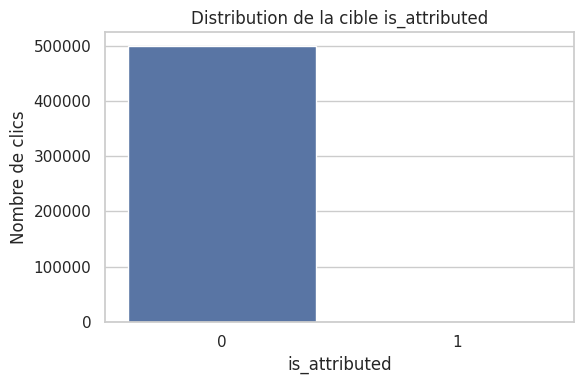

In [5]:
target_counts = df["is_attributed"].value_counts()
target_rate = df["is_attributed"].value_counts(normalize=True) * 100

print("Distribution brute :")
print(target_counts)

print("\nDistribution en pourcentage :")
print(target_rate)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_attributed")
plt.title("Distribution de la cible is_attributed")
plt.xlabel("is_attributed")
plt.ylabel("Nombre de clics")
plt.tight_layout()
plt.savefig(FIG_DIR / "target_distribution.png", dpi=150)
plt.show()

## 9. Prétraitement temporel

On transforme `click_time` et `attributed_time` en dates, puis on extrait des variables temporelles utiles.

In [6]:
df["click_time"] = pd.to_datetime(df["click_time"], errors="coerce")
df["attributed_time"] = pd.to_datetime(df["attributed_time"], errors="coerce")

df = df.dropna(subset=["click_time"])

df["hour"] = df["click_time"].dt.hour
df["day"] = df["click_time"].dt.day
df["minute"] = df["click_time"].dt.minute
df["dayofweek"] = df["click_time"].dt.dayofweek

display(df[["click_time", "hour", "day", "minute", "dayofweek", "is_attributed"]].head())

,click_time,hour,day,minute,dayofweek,is_attributed
0,2017-11-06 14:32:21,14,6,32,0,0
1,2017-11-06 14:33:34,14,6,33,0,0
2,2017-11-06 14:34:12,14,6,34,0,0
3,2017-11-06 14:34:52,14,6,34,0,0
4,2017-11-06 14:35:08,14,6,35,0,0


## 10. Analyse temporelle des clics

On observe la répartition des clics et des conversions par heure.

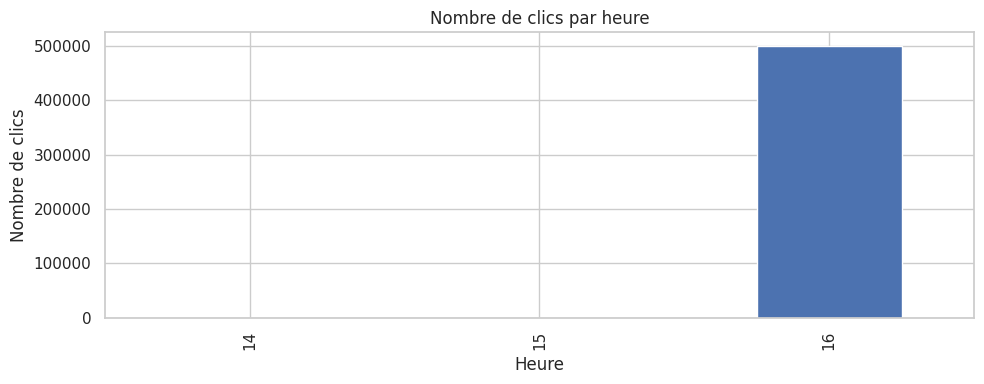

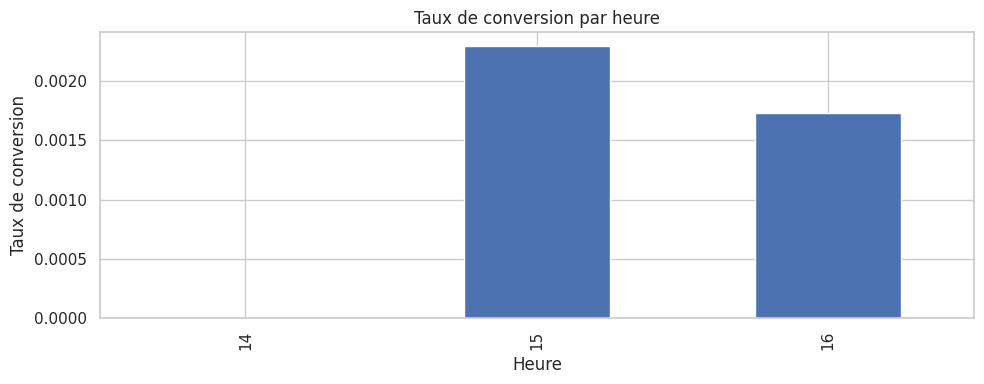

In [7]:
hourly_clicks = df.groupby("hour").size()
hourly_conversion_rate = df.groupby("hour")["is_attributed"].mean()

plt.figure(figsize=(10, 4))
hourly_clicks.plot(kind="bar")
plt.title("Nombre de clics par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre de clics")
plt.tight_layout()
plt.savefig(FIG_DIR / "clicks_by_hour.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
hourly_conversion_rate.plot(kind="bar")
plt.title("Taux de conversion par heure")
plt.xlabel("Heure")
plt.ylabel("Taux de conversion")
plt.tight_layout()
plt.savefig(FIG_DIR / "conversion_rate_by_hour.png", dpi=150)
plt.show()

## 11. Analyse des variables catégorielles

Les colonnes `ip`, `app`, `device`, `os` et `channel` sont des catégories encodées en nombres.

,unique_count
ip,31395
app,182
device,171
channel,145
os,136


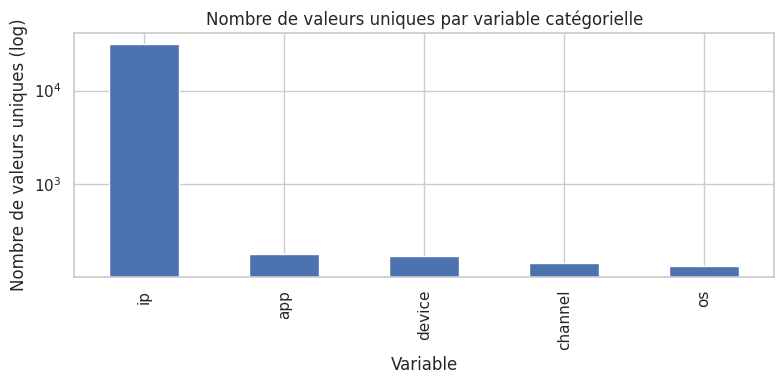

In [8]:
cat_cols = ["ip", "app", "device", "os", "channel"]

unique_counts = df[cat_cols].nunique().sort_values(ascending=False)
display(unique_counts.to_frame("unique_count"))

plt.figure(figsize=(8, 4))
unique_counts.plot(kind="bar", logy=True)
plt.title("Nombre de valeurs uniques par variable catégorielle")
plt.xlabel("Variable")
plt.ylabel("Nombre de valeurs uniques (log)")
plt.tight_layout()
plt.savefig(FIG_DIR / "unique_counts_categories.png", dpi=150)
plt.show()

## 12. Top IP, applications et canaux

Cette analyse aide à repérer des sources à volume anormalement élevé.

In [9]:
for col in ["ip", "app", "device", "os", "channel"]:
    top_values = df[col].value_counts().head(10)
    print(f"\nTop 10 - {col}")
    display(top_values.to_frame("click_count"))


Top 10 - ip


,click_count
ip,
73487,3296
73516,3133
5314,1733
105560,1651
5348,1598
53454,1569
105475,1547
100275,1420
201182,1315



Top 10 - app


,click_count
app,
12,69497
3,65991
9,59537
15,56109
2,53879
18,38763
8,32361
1,19091
14,17431



Top 10 - device


,click_count
device,
1,467914
2,26018
3032,4083
0,1417
59,135
40,21
18,19
21,15
6,15



Top 10 - os


,click_count
os,
19,120453
13,110115
17,26717
18,24717
22,18179
8,15263
10,14836
6,12778
9,12357



Top 10 - channel


,click_count
channel,
134,43940
245,42657
145,31640
259,24335
280,22283
178,21830
477,20041
121,18947
107,14818


## 13. Feature engineering comportemental

On crée des variables qui décrivent le comportement des clics :

- volume de clics par IP ;
- volume par IP et heure ;
- diversité des apps par IP ;
- diversité des channels par IP ;
- temps depuis le clic précédent ;
- combinaisons IP/app/device/channel.

Ces variables sont plus proches du sujet de fraude au clic que les variables brutes.

In [10]:
def add_behavioral_features(data):
    data = data.copy()
    data = data.sort_values(["ip", "click_time"]).reset_index(drop=True)

    # Volumes globaux
    data["ip_click_count"] = data.groupby("ip")["ip"].transform("count")
    data["app_click_count"] = data.groupby("app")["app"].transform("count")
    data["device_click_count"] = data.groupby("device")["device"].transform("count")
    data["os_click_count"] = data.groupby("os")["os"].transform("count")
    data["channel_click_count"] = data.groupby("channel")["channel"].transform("count")

    # Volumes combinés
    data["ip_hour_click_count"] = data.groupby(["ip", "hour"])["ip"].transform("count")
    data["ip_app_click_count"] = data.groupby(["ip", "app"])["ip"].transform("count")
    data["ip_device_click_count"] = data.groupby(["ip", "device"])["ip"].transform("count")
    data["ip_channel_click_count"] = data.groupby(["ip", "channel"])["ip"].transform("count")

    # Diversité par IP
    data["ip_unique_apps"] = data.groupby("ip")["app"].transform("nunique")
    data["ip_unique_devices"] = data.groupby("ip")["device"].transform("nunique")
    data["ip_unique_os"] = data.groupby("ip")["os"].transform("nunique")
    data["ip_unique_channels"] = data.groupby("ip")["channel"].transform("nunique")

    # Temps depuis le clic précédent de la même IP
    data["prev_click_time"] = data.groupby("ip")["click_time"].shift(1)
    data["time_since_prev_click_sec"] = (
        data["click_time"] - data["prev_click_time"]
    ).dt.total_seconds()
    data["time_since_prev_click_sec"] = data["time_since_prev_click_sec"].fillna(-1)

    # Indicateur de clic très rapide
    data["very_fast_repeat_click"] = (
        (data["time_since_prev_click_sec"] >= 0) &
        (data["time_since_prev_click_sec"] <= 5)
    ).astype(int)

    data = data.drop(columns=["prev_click_time"])
    return data

df_fe = add_behavioral_features(df)

print("Dimensions après feature engineering :", df_fe.shape)
display(df_fe.head())

Dimensions après feature engineering : (500000, 27)


,ip,app,device,os,channel,click_time,attributed_time,is_attributed,hour,day,minute,dayofweek,ip_click_count,app_click_count,device_click_count,os_click_count,channel_click_count,ip_hour_click_count,ip_app_click_count,ip_device_click_count,ip_channel_click_count,ip_unique_apps,ip_unique_devices,ip_unique_os,ip_unique_channels,time_since_prev_click_sec,very_fast_repeat_click
0,9,18,1,13,107,2017-11-06 16:02:30,NaT,0,16,6,2,0,2,38763,467914,110115,14818,2,2,2,2,1,1,1,1,-1.0,0
1,9,18,1,13,107,2017-11-06 16:02:41,NaT,0,16,6,2,0,2,38763,467914,110115,14818,2,2,2,2,1,1,1,1,11.0,0
2,10,64,1,22,459,2017-11-06 16:06:34,NaT,0,16,6,6,0,1,6423,467914,18179,10801,1,1,1,1,1,1,1,1,-1.0,0
3,25,18,1,18,107,2017-11-06 16:05:47,NaT,0,16,6,5,0,7,38763,467914,24717,14818,7,1,7,1,6,1,2,7,-1.0,0
4,25,15,1,13,245,2017-11-06 16:06:16,NaT,0,16,6,6,0,7,56109,467914,110115,42657,7,1,7,1,6,1,2,7,29.0,0


## 14. Profil des clics convertis vs non convertis

On compare les comportements moyens selon la cible.

In [11]:
behavior_cols = [
    "ip_click_count",
    "ip_hour_click_count",
    "ip_app_click_count",
    "ip_device_click_count",
    "ip_channel_click_count",
    "ip_unique_apps",
    "ip_unique_devices",
    "ip_unique_os",
    "ip_unique_channels",
    "time_since_prev_click_sec",
    "very_fast_repeat_click",
]

profile = df_fe.groupby("is_attributed")[behavior_cols].mean().T
profile.columns = ["non_converted_mean", "converted_mean"]
profile["gap"] = profile["converted_mean"] - profile["non_converted_mean"]
display(profile)

profile.to_csv(TABLE_DIR / "converted_vs_nonconverted_profile.csv")

,non_converted_mean,converted_mean,gap
ip_click_count,157.783913,70.033565,-87.750348
ip_hour_click_count,157.638223,70.000000,-87.638223
ip_app_click_count,21.270311,2.914352,-18.355959
ip_device_click_count,129.607618,47.752315,-81.855303
ip_channel_click_count,11.666726,2.545139,-9.121587
ip_unique_apps,12.378448,6.363426,-6.015022
ip_unique_devices,1.728479,1.405093,-0.323386
ip_unique_os,9.358992,4.585648,-4.773344
ip_unique_channels,22.917031,10.679398,-12.237632
time_since_prev_click_sec,15.718500,20.510417,4.791917


## 15. Détection d’anomalies avec Isolation Forest

Isolation Forest détecte les clics dont le comportement est inhabituel.

Ici, l’objectif est de produire un signal `anomaly_score`, pas de prouver la fraude.

Taux d'anomalies détectées : 0.03


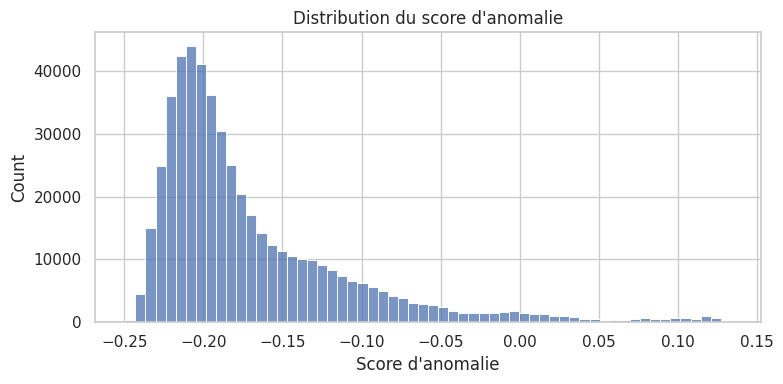

In [12]:
anomaly_features = [
    "ip_click_count",
    "app_click_count",
    "device_click_count",
    "os_click_count",
    "channel_click_count",
    "ip_hour_click_count",
    "ip_app_click_count",
    "ip_device_click_count",
    "ip_channel_click_count",
    "ip_unique_apps",
    "ip_unique_devices",
    "ip_unique_os",
    "ip_unique_channels",
    "time_since_prev_click_sec",
    "very_fast_repeat_click",
    "hour",
    "day",
    "minute",
]

anom_df = df_fe[anomaly_features].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler_anom = StandardScaler()
X_anom = scaler_anom.fit_transform(anom_df)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso.fit(X_anom)

df_fe["anomaly_flag"] = (iso.predict(X_anom) == -1).astype(int)
df_fe["anomaly_score"] = -iso.decision_function(X_anom)

print("Taux d'anomalies détectées :", df_fe["anomaly_flag"].mean())

plt.figure(figsize=(8, 4))
sns.histplot(df_fe["anomaly_score"], bins=60)
plt.title("Distribution du score d'anomalie")
plt.xlabel("Score d'anomalie")
plt.tight_layout()
plt.savefig(FIG_DIR / "anomaly_score_distribution.png", dpi=150)
plt.show()

## 16. Top clics suspects selon Isolation Forest

In [13]:
suspect_clicks = df_fe.sort_values("anomaly_score", ascending=False).head(20)
display(suspect_clicks[
    ["ip", "app", "device", "os", "channel", "click_time",
     "ip_click_count", "ip_hour_click_count", "time_since_prev_click_sec",
     "very_fast_repeat_click", "anomaly_score", "anomaly_flag", "is_attributed"]
])

,ip,app,device,os,channel,click_time,ip_click_count,ip_hour_click_count,time_since_prev_click_sec,very_fast_repeat_click,anomaly_score,anomaly_flag,is_attributed
223844,73516,3,1,19,153,2017-11-06 16:00:59,3133,3133,1.0,1,0.133602,1,0
224775,73516,12,1,19,326,2017-11-06 16:03:50,3133,3133,2.0,1,0.133416,1,0
223643,73516,12,1,19,245,2017-11-06 16:00:24,3133,3133,0.0,1,0.133075,1,0
223719,73516,3,2,19,153,2017-11-06 16:00:39,3133,3133,0.0,1,0.133063,1,0
226092,73516,12,2,19,245,2017-11-06 16:08:00,3133,3133,0.0,1,0.132547,1,0
223840,73516,3,1,19,153,2017-11-06 16:00:58,3133,3133,0.0,1,0.132332,1,0
223755,73516,3,1,19,153,2017-11-06 16:00:45,3133,3133,0.0,1,0.132332,1,0
223725,73516,3,1,19,153,2017-11-06 16:00:40,3133,3133,0.0,1,0.132332,1,0
223735,73516,12,1,19,326,2017-11-06 16:00:41,3133,3133,0.0,1,0.131400,1,0
223776,73516,12,1,19,326,2017-11-06 16:00:50,3133,3133,0.0,1,0.131400,1,0


## 17. Préparation du dataset pour le modèle supervisé

On entraîne un modèle pour prédire la probabilité de conversion `is_attributed`.

Dans l’application finale :

- probabilité de conversion élevée → clic probablement utile ;
- probabilité de conversion faible + anomalie élevée → clic suspect ou faible qualité.

In [14]:
model_features = [
    "ip", "app", "device", "os", "channel",
    "hour", "day", "minute", "dayofweek",
    "ip_click_count",
    "app_click_count",
    "device_click_count",
    "os_click_count",
    "channel_click_count",
    "ip_hour_click_count",
    "ip_app_click_count",
    "ip_device_click_count",
    "ip_channel_click_count",
    "ip_unique_apps",
    "ip_unique_devices",
    "ip_unique_os",
    "ip_unique_channels",
    "time_since_prev_click_sec",
    "very_fast_repeat_click",
    "anomaly_score",
    "anomaly_flag",
]

X = df_fe[model_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df_fe["is_attributed"].astype(int)

print("X :", X.shape)
print("y :", y.shape)
print("Taux de conversion :", y.mean())

X : (500000, 26)
y : (500000,)
Taux de conversion : 0.001728


## 18. Split train/test

On utilise un split stratifié pour préserver le déséquilibre des classes.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)
print("Taux conversion train :", y_train.mean())
print("Taux conversion test :", y_test.mean())

Train : (400000, 26)
Test : (100000, 26)
Taux conversion train : 0.0017275
Taux conversion test : 0.00173


## 19. Modèle 1 — Logistic Regression

Modèle simple, interprétable, utile comme baseline.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr.fit(X_train_scaled, y_train)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

## 20. Modèle 2 — Random Forest

Modèle non linéaire capable de capturer des interactions entre IP, appareil, canal et temps.

In [17]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=16,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]

## 21. Modèle 3 — XGBoost si disponible

XGBoost est souvent performant sur les données tabulaires.  
Si la bibliothèque n’est pas disponible, la cellule passe sans bloquer le notebook.

In [18]:
xgb_model = None
xgb_prob = None
xgb_error = None

try:
    from xgboost import XGBClassifier

    positives = max(1, int((y_train == 1).sum()))
    negatives = max(1, int((y_train == 0).sum()))
    scale_pos_weight = negatives / positives

    xgb_model = XGBClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

    xgb_model.fit(X_train, y_train)
    xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
    print("XGBoost entraîné avec succès.")

except Exception as exc:
    xgb_error = str(exc)
    print("XGBoost indisponible :", xgb_error)

XGBoost entraîné avec succès.


## 22. Évaluation des modèles

Comme la cible est très déséquilibrée, les métriques prioritaires sont :

- PR-AUC ;
- Recall ;
- F1-score ;
- ROC-AUC.

In [19]:
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "model": name,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }

results = []
results.append(evaluate_model("Logistic Regression", y_test, lr_prob))
results.append(evaluate_model("Random Forest", y_test, rf_prob))

if xgb_prob is not None:
    results.append(evaluate_model("XGBoost", y_test, xgb_prob))

results_df = pd.DataFrame(results)
display(results_df[["model", "roc_auc", "pr_auc", "precision", "recall", "f1"]])

results_df.to_csv(TABLE_DIR / "model_metrics.csv", index=False)

,model,roc_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.904150,0.093896,0.011744,0.786127,0.023143
1,Random Forest,0.941558,0.361524,0.202925,0.641618,0.308333
2,XGBoost,0.940358,0.371754,0.106239,0.728324,0.185430


## 23. Courbes ROC et Precision-Recall

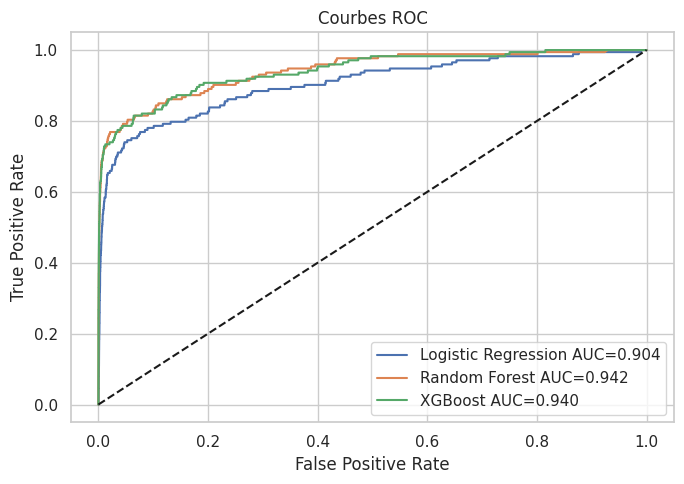

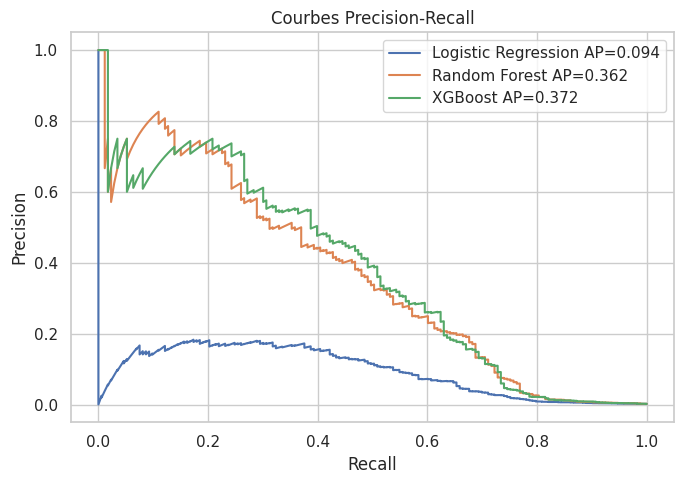

In [20]:
probs = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
}

if xgb_prob is not None:
    probs["XGBoost"] = xgb_prob

plt.figure(figsize=(7, 5))
for name, prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], "k--")
plt.title("Courbes ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
for name, prob in probs.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} AP={ap:.3f}")

plt.title("Courbes Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "pr_curves.png", dpi=150)
plt.show()

## 24. Choix du modèle final

On choisit le modèle avec la meilleure PR-AUC.

Dans un problème déséquilibré, PR-AUC est plus informative que l’accuracy.

In [21]:
best_row = results_df.sort_values("pr_auc", ascending=False).iloc[0]
best_model_name = best_row["model"]

if best_model_name == "XGBoost":
    final_model = xgb_model
    final_uses_scaler = False
elif best_model_name == "Random Forest":
    final_model = rf
    final_uses_scaler = False
else:
    final_model = lr
    final_uses_scaler = True

print("Meilleur modèle :", best_model_name)
print(best_row)

Meilleur modèle : XGBoost
model                                  XGBoost
roc_auc                               0.940358
pr_auc                                0.371754
precision                             0.106239
recall                                0.728324
f1                                     0.18543
confusion_matrix    [[98767, 1060], [47, 126]]
Name: 2, dtype: object


## 25. Création d’un score de risque

Pour l’intégration web temps réel, on convertit les sorties du modèle en score de risque.

Logique :

- `conversion_probability` : probabilité que le clic mène à une conversion ;
- `low_quality_score = 1 - conversion_probability` ;
- `risk_score` combine faible probabilité de conversion et score d’anomalie.

Décision :

- `allow` : risque faible ;
- `monitor` : risque moyen ;
- `block` : risque élevé.

In [22]:
def minmax_scale(series):
    s = pd.Series(series)
    if s.max() == s.min():
        return np.zeros(len(s))
    return (s - s.min()) / (s.max() - s.min())

if final_uses_scaler:
    final_prob = final_model.predict_proba(X_test_scaled)[:, 1]
else:
    final_prob = final_model.predict_proba(X_test)[:, 1]

risk_eval = X_test.copy()
risk_eval["conversion_probability"] = final_prob
risk_eval["low_quality_score"] = 1 - risk_eval["conversion_probability"]
risk_eval["anomaly_score_scaled"] = minmax_scale(risk_eval["anomaly_score"])

risk_eval["risk_score"] = (
    0.70 * risk_eval["low_quality_score"] +
    0.30 * risk_eval["anomaly_score_scaled"]
)

def decision_from_score(score):
    if score >= 0.80:
        return "block"
    elif score >= 0.50:
        return "monitor"
    return "allow"

risk_eval["decision"] = risk_eval["risk_score"].apply(decision_from_score)

display(risk_eval[["conversion_probability", "low_quality_score", "anomaly_score_scaled", "risk_score", "decision"]].head())

print(risk_eval["decision"].value_counts(normalize=True) * 100)

,conversion_probability,low_quality_score,anomaly_score_scaled,risk_score,decision
298933,0.085020,0.914980,0.273079,0.722410,monitor
138976,0.039459,0.960541,0.138129,0.713817,monitor
283764,0.011884,0.988116,0.086354,0.717587,monitor
49620,0.004167,0.995833,0.058281,0.714567,monitor
434627,0.085140,0.914860,0.171209,0.691765,monitor


decision
monitor    83.876
block      13.988
allow       2.136
Name: proportion, dtype: float64


## 26. Analyse des décisions

On observe la distribution des décisions du système.

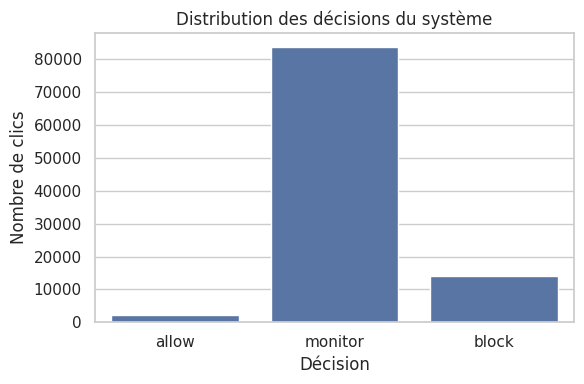

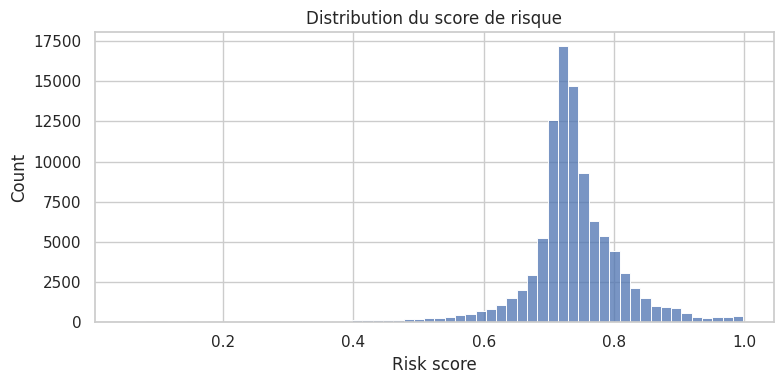

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(data=risk_eval, x="decision", order=["allow", "monitor", "block"])
plt.title("Distribution des décisions du système")
plt.xlabel("Décision")
plt.ylabel("Nombre de clics")
plt.tight_layout()
plt.savefig(FIG_DIR / "decision_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(risk_eval["risk_score"], bins=60)
plt.title("Distribution du score de risque")
plt.xlabel("Risk score")
plt.tight_layout()
plt.savefig(FIG_DIR / "risk_score_distribution.png", dpi=150)
plt.show()

## 27. Analyse ROI simulée

Le dataset ne contient pas le coût publicitaire réel ni le revenu par conversion.  
On simule donc des paramètres business réalistes pour montrer l’impact du filtrage.

Hypothèses :

- coût par clic : `0.05` ;
- revenu par conversion : `5.00` ;
- les clics `block` sont exclus.

,scenario,clicks,conversions,cost,revenue,roi
0,before_filtering,100000,173,5000.0,865.0,-0.827000
1,after_filtering,86012,167,4300.6,835.0,-0.805841


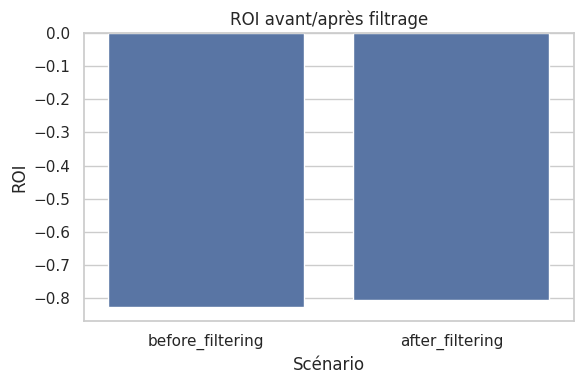

In [24]:
roi_df = risk_eval.copy()
roi_df["is_attributed"] = y_test.values

COST_PER_CLICK = 0.05
REVENUE_PER_CONVERSION = 5.00

total_clicks_before = len(roi_df)
conversions_before = roi_df["is_attributed"].sum()
cost_before = total_clicks_before * COST_PER_CLICK
revenue_before = conversions_before * REVENUE_PER_CONVERSION
roi_before = (revenue_before - cost_before) / cost_before

filtered_df = roi_df[roi_df["decision"] != "block"]

total_clicks_after = len(filtered_df)
conversions_after = filtered_df["is_attributed"].sum()
cost_after = total_clicks_after * COST_PER_CLICK
revenue_after = conversions_after * REVENUE_PER_CONVERSION
roi_after = (revenue_after - cost_after) / cost_after

roi_summary = pd.DataFrame([
    {
        "scenario": "before_filtering",
        "clicks": total_clicks_before,
        "conversions": int(conversions_before),
        "cost": cost_before,
        "revenue": revenue_before,
        "roi": roi_before,
    },
    {
        "scenario": "after_filtering",
        "clicks": total_clicks_after,
        "conversions": int(conversions_after),
        "cost": cost_after,
        "revenue": revenue_after,
        "roi": roi_after,
    }
])

display(roi_summary)
roi_summary.to_csv(TABLE_DIR / "roi_summary.csv", index=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=roi_summary, x="scenario", y="roi")
plt.title("ROI avant/après filtrage")
plt.xlabel("Scénario")
plt.ylabel("ROI")
plt.tight_layout()
plt.savefig(FIG_DIR / "roi_before_after.png", dpi=150)
plt.show()

## 28. Export des artefacts pour l’application web

On sauvegarde :

- le modèle final ;
- le scaler si nécessaire ;
- le scaler d’anomalie ;
- le modèle Isolation Forest ;
- la liste des features ;
- les métriques ;
- un échantillon de clics scorés.

Ces fichiers seront utilisés dans l’API FastAPI et le dashboard.

In [25]:
joblib.dump(final_model, MODEL_DIR / "fraud_model.pkl")
joblib.dump(iso, MODEL_DIR / "isolation_forest.pkl")
joblib.dump(scaler_anom, MODEL_DIR / "anomaly_scaler.pkl")

if final_uses_scaler:
    joblib.dump(scaler, MODEL_DIR / "supervised_scaler.pkl")

metadata = {
    "best_model_name": best_model_name,
    "final_uses_scaler": final_uses_scaler,
    "model_features": model_features,
    "anomaly_features": anomaly_features,
    "risk_formula": "0.70 * low_quality_score + 0.30 * anomaly_score_scaled",
    "thresholds": {
        "allow": "risk_score < 0.50",
        "monitor": "0.50 <= risk_score < 0.80",
        "block": "risk_score >= 0.80"
    },
    "business_assumptions": {
        "cost_per_click": COST_PER_CLICK,
        "revenue_per_conversion": REVENUE_PER_CONVERSION
    },
    "xgb_error": xgb_error,
}

with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

with open(TABLE_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

risk_eval.head(5000).to_csv(TABLE_DIR / "scored_clicks_sample.csv", index=False)

print("Artefacts sauvegardés dans :", MODEL_DIR)
print("Tables sauvegardées dans :", TABLE_DIR)

Artefacts sauvegardés dans : /kaggle/working/models
Tables sauvegardées dans : /kaggle/working/tables


## 29. Exemple de sortie attendue pour l’API temps réel

L’API recevra un clic sous forme JSON :

```json
{
  "ip": 83230,
  "app": 3,
  "device": 1,
  "os": 13,
  "channel": 379,
  "click_time": "2026-04-24 14:30:00"
}
```

Elle retournera :

```json
{
  "conversion_probability": 0.08,
  "risk_score": 0.87,
  "decision": "block",
  "reason": "High risk score and abnormal click pattern"
}
```

Cette partie sera développée dans FastAPI après l’entraînement du modèle.

## 30. Conclusion

Ce notebook représente la partie data science du projet.

Résultats produits :

- exploration du dataset TalkingData ;
- prétraitement temporel ;
- création de variables comportementales ;
- détection d’anomalies ;
- modèles supervisés de prédiction ;
- score de risque ;
- simulation ROI ;
- exports pour API et dashboard.

Limites :

- `is_attributed = 0` ne signifie pas fraude certaine ;
- le dataset ne contient pas de vraies étiquettes juridiques de fraude ;
- le score détecte surtout des clics suspects ou de faible qualité ;
- le ROI est simulé car les coûts réels ne sont pas fournis.

Prochaine étape :

Intégrer le modèle dans une API FastAPI puis créer un site web de simulation et un dashboard Streamlit.